# Logistic Regression

$$ f_{\mathbf{w},b}(x) = g(\mathbf{w}\cdot \mathbf{x} + b)$$


# 

In [49]:
import numpy as np
from numpy.typing import NDArray
import matplotlib.pyplot as plt

from logistic_regression import LogisticRegression

from utils import *

## Sigmoid
$$g(z) = \frac{1}{1+e^{-z}}$$

## Cost Fuction

Linear Regression
$$
J(w,b) = \frac{1}{2m} \sum \limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})^{2} \tag{1}
$$ 

Logistic Regression
$$
J(\mathbf{w},b) = \frac{1}{m}\sum_{i=0}^{m-1} \left[ loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)}) \right] \tag{1}
$$
$$loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)}) = (-y^{(i)} \log\left(f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) - \left( 1 - y^{(i)}\right) \log \left( 1 - f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) \tag{2}$$


## Gradient descent

$$
\begin{align}
\frac{\partial J(w,b)}{\partial w}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})x^{(i)} \tag{4}\\
  \frac{\partial J(w,b)}{\partial b}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)}) \tag{5}\\
\end{align}
$$

## Training

In [41]:
def sigmoid(z: NDArray):
    g = 1 / (1 + np.exp(-z))
    return g

def map_feature(X1, X2):
    """
    Feature mapping function to polynomial features    
    """
    X1 = np.atleast_1d(X1)
    X2 = np.atleast_1d(X2)
    degree = 6
    out = []
    for i in range(1, degree+1):
        for j in range(i + 1):
            out.append((X1**(i-j) * (X2**j)))
    return np.stack(out, axis=1)


def plot_data(X, y, pos_label="y=1", neg_label="y=0"):
    positive = y == 1
    negative = y == 0
    
    # Plot examples
    plt.plot(X[positive, 0], X[positive, 1], 'k+', label=pos_label)
    plt.plot(X[negative, 0], X[negative, 1], 'yo', label=neg_label)

def plot_decision_boundary(X, y, w, b):
    # Credit to dibgerge on Github for this plotting code
     
    plot_data(X, y)
    
    if X.shape[1] <= 2:
        plot_x = np.array([min(X[:, 0]), max(X[:, 0])])
        plot_y = (-1. / w[1]) * (w[0] * plot_x + b)
        
        plt.plot(plot_x, plot_y, c="b")
        
    else:
        u = np.linspace(-1, 1.5, 50)
        v = np.linspace(-1, 1.5, 50)
        
        z = np.zeros((len(u), len(v)))

        # Evaluate z = theta*x over the grid
        for i in range(len(u)):
            for j in range(len(v)):
                z[i,j] = sigmoid((np.dot(map_feature(u[i], v[j]), w)).item() + b)
        
        # important to transpose z before calling contour       
        z = z.T
        
        # Plot z = 0
        plt.contour(u,v,z, levels = [0.5], colors="g")


         0 - Cost: 0.96379018
      1000 - Cost: 0.30509033
      2000 - Cost: 0.30472281
      3000 - Cost: 0.30435771
      4000 - Cost: 0.30399500
      5000 - Cost: 0.30363467
      6000 - Cost: 0.30327668
      7000 - Cost: 0.30292101
      8000 - Cost: 0.30256764
      9000 - Cost: 0.30221655


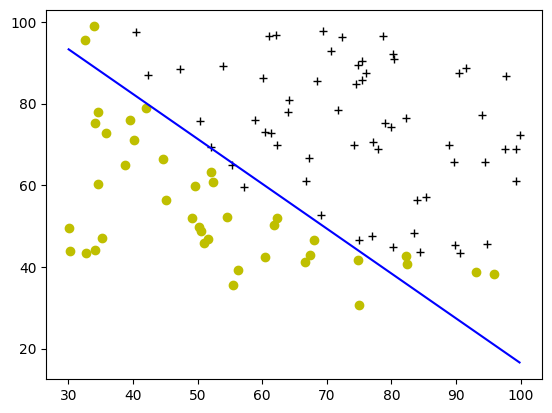

In [42]:
np.random.seed(1)

ex_data_file = "data/ex2data1.txt"
X_train, y_train = load_data(ex_data_file)

w_init = 0.01 * (np.random.rand(X_train.shape[1]) - 0.5)
b_init = -8

alpha = 1.0e-3
iters_num = 10000

log_reg = LogisticRegression(X_train, y_train)
w, b, J_history, p_history = log_reg.fit(w_init, b_init, alpha, iters_num)
plot_decision_boundary(X_train, y_train, w, b)

In [43]:
def test_predict(X, model):
    p_hat = model.predict(X)
    m = X.shape[0]
    p = np.zeros(m)
    for i in range(m):
        p[i] = 1 if p_hat[i] > 0.5 else 0
    print(w, b)
    print(f'Train Accuracy: {np.mean(p == y_train) * 100:3.2f}')

test_predict(X_train, log_reg)

[0.07125355 0.06482888] -8.188622906639248
Train Accuracy: 92.00


## Regularized Logistic Regression 

X_train: (118, 2)
y_train: (118,)


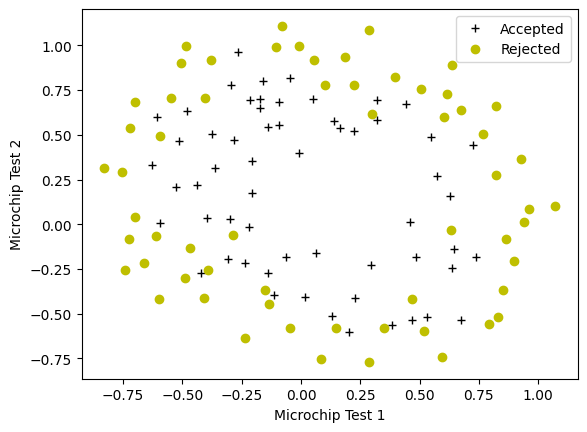

In [44]:
X_train, y_train = load_data("data/ex2data2.txt")
print(f'X_train: {X_train.shape}')
print(f'y_train: {y_train.shape}')

plot_data(X_train, y_train[:], pos_label="Accepted", neg_label="Rejected")

# Set the y-axis label
plt.ylabel('Microchip Test 2') 
# Set the x-axis label
plt.xlabel('Microchip Test 1') 
plt.legend(loc="upper right")
plt.show()

In [46]:
print("Original shape of data:", X_train.shape)
X_mapped =  map_feature(X_train[:, 0], X_train[:, 1])
print("Shape after feature mapping:", X_mapped.shape)

Original shape of data: (118, 2)
Shape after feature mapping: (118, 27)


## Cost Function for regularizaiton
$$
J(\mathbf{w},b) = \frac{1}{m}  \sum_{i=0}^{m-1} \left[ -y^{(i)} \log\left(f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) - \left( 1 - y^{(i)}\right) \log \left( 1 - f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) \right] + \frac{\lambda}{2m}  \sum_{j=0}^{n-1} w_j^2
$$

         0 - Cost: 0.72091805
      1000 - Cost: 0.58726318
      2000 - Cost: 0.55683635
      3000 - Cost: 0.53274195
      4000 - Cost: 0.51308668
      5000 - Cost: 0.49673495
      6000 - Cost: 0.48291027
      7000 - Cost: 0.47106354
      8000 - Cost: 0.46079548
      9000 - Cost: 0.45180872


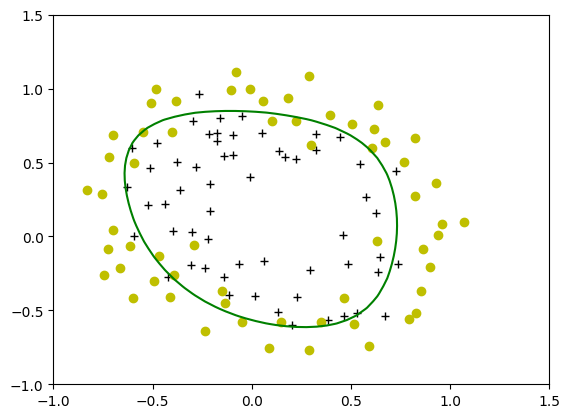

In [47]:
np.random.seed(1) 
w_in = np.random.rand(X_mapped.shape[1]) - 0.5
b_in = 1.
alpha = 0.01
iterations = 10000
lambda_ = 0.01;                                          

model_reg = LogisticRegression(X_mapped, y_train) 
w, b, J_history, p_history = model_reg.fit(w_in, b_in, alpha, iterations, lambda_)
plot_decision_boundary(X_mapped, y_train, w, b)

## Predict

In [48]:
test_predict(X_mapped, model_reg)

[ 0.91942591  1.498808   -2.60245258 -1.02553909 -1.71585623 -0.09592211
 -0.71160079 -0.45730613 -0.26340681 -1.50698147 -0.14270698 -0.44153586
 -0.52508092 -0.85837858 -0.62573584 -0.07261085 -0.11805904 -0.22722724
 -0.62605666 -0.82141607 -0.81504549  0.47841069 -0.48917343  0.20341741
  0.03868363  0.28008285 -1.44112378] 1.4386736500564226
Train Accuracy: 82.20
